In [2]:
import json
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path(r"C:\Users\mahas\Audio-Processing\results")
print("Results dir exists:", RESULTS_DIR.exists())
print("Files:", [f.name for f in RESULTS_DIR.iterdir()])

Results dir exists: True
Files: ['batch_summary.json', 'CBLbDPmmx4M.rttm', 'CBLbDPmmx4M_annotations.json', 'CBLbDPmmx4M_diarization.json', 'CBLbDPmmx4M_emotion.json', 'provenance_manifest.csv']


In [3]:
with open(RESULTS_DIR / "CBLbDPmmx4M_annotations.json") as f:
    annotation = json.load(f)

print(f"Video: {annotation['video_id']}")
print(f"Duration: {annotation['audio']['duration']:.1f}s")
print(f"Speakers: {annotation['diarization_validation']['num_speakers']}")
print(f"Segments: {len(annotation['segments'])}")
print(f"Licence: {annotation['provenance']['licence_tier']}")
print(f"Uploader: {annotation['provenance']['uploader']}")

Video: CBLbDPmmx4M
Duration: 80.0s
Speakers: 1
Segments: 23
Licence: OPEN
Uploader: The World of Audiobooks


In [4]:
df = pd.DataFrame(annotation["segments"])
df[["start", "end", "speaker", "emotion", "emotion_confidence", "emotion_flag"]].head(20)

,start,end,speaker,emotion,emotion_confidence,emotion_flag
0,0.008,0.688,SPEAKER_00,NaN,NaN,SKIPPED_TOO_SHORT
1,0.739,9.431,SPEAKER_00,sad,0.1326,LOW_CONFIDENCE
2,11.570,12.131,SPEAKER_00,NaN,NaN,SKIPPED_TOO_SHORT
3,12.810,15.424,SPEAKER_00,surprised,0.1309,LOW_CONFIDENCE
4,16.290,17.581,SPEAKER_00,surprised,0.1303,LOW_CONFIDENCE
5,18.752,20.059,SPEAKER_00,surprised,0.1305,LOW_CONFIDENCE
6,20.603,21.214,SPEAKER_00,NaN,NaN,SKIPPED_TOO_SHORT
7,21.520,22.334,SPEAKER_00,NaN,NaN,SKIPPED_TOO_SHORT
8,22.895,24.049,SPEAKER_00,surprised,0.1330,LOW_CONFIDENCE
9,24.677,26.053,SPEAKER_00,surprised,0.1309,LOW_CONFIDENCE


In [5]:
manifest = pd.read_csv(RESULTS_DIR / "provenance_manifest.csv")
manifest

,video_id,source_url,uploader,licence_tier,gate_passed,blocked_reason,retrieved_at
0,CBLbDPmmx4M,https://www.youtube.com/watch?v=CBLbDPmmx4M,The World of Audiobooks,OPEN,True,NaN,2026-06-06T12:18:40.915297Z


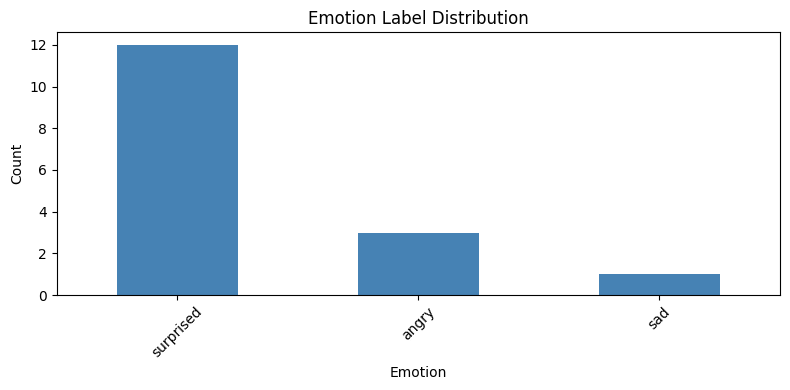

In [6]:
import matplotlib.pyplot as plt

df_tagged = df[df["emotion"].notna()]

emotion_counts = df_tagged["emotion"].value_counts()
emotion_counts.plot(kind="bar", figsize=(8, 4), title="Emotion Label Distribution", color="steelblue")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "emotion_distribution.png")
plt.show()

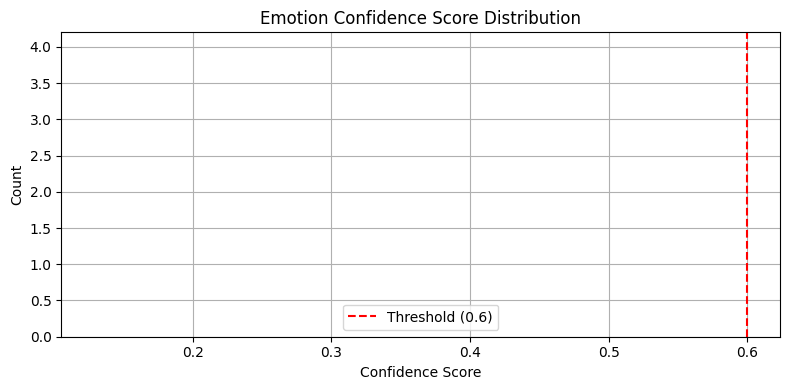

In [7]:
df["emotion_confidence"].dropna().hist(bins=15, figsize=(8, 4), color="steelblue", edgecolor="white")
plt.title("Emotion Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.axvline(x=0.6, color="red", linestyle="--", label="Threshold (0.6)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confidence_distribution.png")
plt.show()

In [8]:
total = len(df)
tagged = df["emotion"].notna().sum()
skipped = (df["emotion_flag"] == "SKIPPED_TOO_SHORT").sum()
low_conf = (df["emotion_flag"] == "LOW_CONFIDENCE").sum()

print("=== PIPELINE SUMMARY ===")
print(f"Audio duration:       {annotation['audio']['duration']:.1f}s")
print(f"Total segments:       {total}")
print(f"Tagged segments:      {tagged}")
print(f"Skipped (too short):  {skipped}")
print(f"Low confidence:       {low_conf} ({100*low_conf/tagged:.0f}% of tagged)")
print(f"Licence tier:         {annotation['provenance']['licence_tier']}")
print(f"Gate passed:          {annotation['provenance']['gate_passed']}")
print(f"\n=== KEY FINDING ===")
print(f"100% of tagged segments fell below the confidence threshold (0.6)")
print(f"This monotone poetry reading would be quarantined from TTS training data")
print(f"demonstrating the safety gate working as intended.")

=== PIPELINE SUMMARY ===
Audio duration:       80.0s
Total segments:       23
Tagged segments:      16
Skipped (too short):  7
Low confidence:       16 (100% of tagged)
Licence tier:         OPEN
Gate passed:          True

=== KEY FINDING ===
100% of tagged segments fell below the confidence threshold (0.6)
This monotone poetry reading would be quarantined from TTS training data
demonstrating the safety gate working as intended.
